# scaling_model_size — analysis

I noticed that the LR bottoms out when training with single precision. This suite tests if switching to double precision makes a difference.

The LR bottoms out for nearly all of the models in `scaling_model_size` when trained for 100k epochs, so I'll start by testing on smaller models.

**Notes:**
* the 64 x 4 model will take 7hrs to run on the CPU in double precision.
* strangely, the LR doesn't drop to the threshold for the models trained on the CPU, unlike those of the same size trained on CUDA. This is probably because I trained the CPU models in double-precision. I should train them in single precision to see what happens.
* Currently running a single precision model on CUDA as a baseline.
Loads `results/summary.parquet` produced by `run.py` and plots how
loss, held-out energy error, and wall time scale with the number of
training orbits.

Re-run `python run.py` whenever the sweep grid changes; this notebook
should never train.

In [1]:
training_steps = 100_000 # 5_000
high_threshold = 1e-7
low_threshold = 1e-13
low_precision = 'float32'
high_precision = 'float64'

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True


df = pd.read_parquet(Path('results') / 'summary.parquet')

df = df[df['training.steps'] == training_steps]
# df = df[df['scheduler.threshold'] == threshold]
df.head()

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,wall_time_s,steps_per_sec,timestamp,git_sha,git_dirty,hostname,platform,python_version,torch_version,run_id
0,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,5185.194482,19.285680,2026-05-20T18:26:16+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,f704384201
1,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,5700.469995,17.542413,2026-05-20T20:01:17+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,1d607d8b74
2,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,12590.175761,7.942701,2026-05-20T23:31:08+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,134c26abdf
3,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,15118.930505,6.614224,2026-05-21T03:43:09+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,0105e5f8fe
4,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,9864.056717,10.137817,2026-05-21T06:27:49+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,6c6ea03cbf


In [3]:
low_prec_df = df[df['dtype'] == low_precision]
high_prec_df = df[df['dtype'] == high_precision]

In [4]:
low_prec_df

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,wall_time_s,steps_per_sec,timestamp,git_sha,git_dirty,hostname,platform,python_version,torch_version,run_id
0,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,5185.194482,19.285680,2026-05-20T18:26:16+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,f704384201
2,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,12590.175761,7.942701,2026-05-20T23:31:08+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,134c26abdf
4,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,9864.056717,10.137817,2026-05-21T06:27:49+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,6c6ea03cbf
6,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,20266.923200,4.934148,2026-05-21T15:01:39+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,fb02c41ddb


In [5]:
df

,data.omega,data.n_orbits,data.n_steps,data.r_bounds,potential.name,model.class,model.input_dim,model.n_layers,model.layer_class,model.conditioner.class,...,wall_time_s,steps_per_sec,timestamp,git_sha,git_dirty,hostname,platform,python_version,torch_version,run_id
0,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,5185.194482,19.285680,2026-05-20T18:26:16+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,f704384201
1,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,5700.469995,17.542413,2026-05-20T20:01:17+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,1d607d8b74
2,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,12590.175761,7.942701,2026-05-20T23:31:08+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,134c26abdf
3,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,32,SymplecticCouplingLayer,SimpleNNConditioner,...,15118.930505,6.614224,2026-05-21T03:43:09+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,0105e5f8fe
4,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,9864.056717,10.137817,2026-05-21T06:27:49+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,6c6ea03cbf
5,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,10562.142232,9.467776,2026-05-21T09:23:52+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,2dc272f292
6,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,20266.923200,4.934148,2026-05-21T15:01:39+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,fb02c41ddb
7,1.5,16,256,"[0.15, 0.75]",MWPotential2014_1D,HamiltonianMappingModel,2,64,SymplecticCouplingLayer,SimpleNNConditioner,...,26378.257734,3.791001,2026-05-21T22:21:19+00:00,4706631,True,geir,Linux-6.8.0-111-generic-x86_64-with-glibc2.39,3.12.3,2.5.1+cu121,4ceeb0bd59


In [6]:
# norbits = 'data.n_orbits'
# agg_norbits = df.groupby(norbits).agg(
#     final_loss_mean=('final_loss', 'mean'),
#     final_loss_std=('final_loss', 'std'),
#     eval_mean_error_max=('eval_mean_error_max', 'mean'),
#     eval_mean_error_max_std=('eval_mean_error_max', 'std'),
#     eval_max_error_mean=('eval_max_error_mean', 'mean'),
#     eval_max_error_max=('eval_max_error_max', 'max'),
#     wall_time_mean=('wall_time_s', 'mean'),
#     wall_time_std=('wall_time_s', 'std'),
# ).reset_index()
# agg_norbits

In [7]:
df['data.n_pts'] = df['data.n_orbits'] * df['data.n_steps']
df['model.complexity'] =df['model.n_layers'] * (((df['model.conditioner.args.num_layers']+1) 
                                                 * df['model.conditioner.args.projection_dims']) +
                  ((df['model.conditioner.args.num_layers'] - 2) * df['model.conditioner.args.projection_dims']**2)
                  + 2
)
df['total_layers'] = df['model.n_layers'] * df['model.conditioner.args.num_layers']
#df['model.n_layers'] * df['model.conditioner.args.num_layers'] * (df['model.conditioner.args.projection_dims'] + 1) # Number of trainable parameters


# Training Evaluation

How well did the models train?

In [8]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.conditioner.args.num_layers'].unique():
#     subset = df[df['model.conditioner.args.num_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Model Complexity (Parameters)', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Conditioner Layers')
# plt.show()

In [9]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Model Complexity (Parameters)', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Flow Layers')
# plt.show()

In [10]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.conditioner.args.num_layers'].unique():
#     subset = df[df['model.conditioner.args.num_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['model.complexity'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Model Complexity (Parameters)', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
#plt.legend(title='Number of Conditioner Layers')

Can also achieve better results for the same time to train with more flow layers.

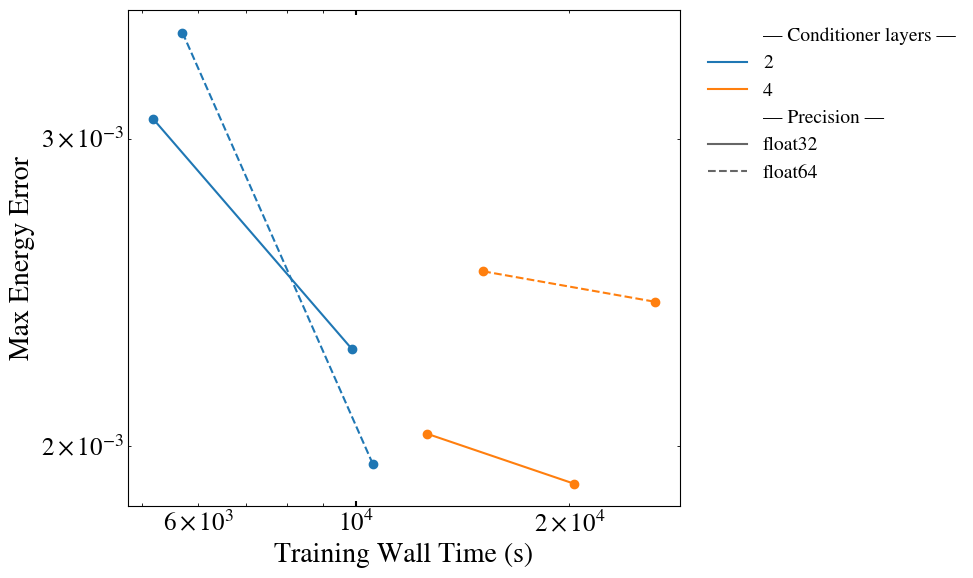

In [11]:
from itertools import cycle
from matplotlib.lines import Line2D

# ---- configuration: reassign these to change the encoding ----
x_col, y_col = 'wall_time_s', 'eval_max_error_max'

# Map visual channel -> dataframe column. Drop a channel to stop encoding it.
encodings = {
    'color':     'model.conditioner.args.num_layers',
    'linestyle': 'dtype'
}
channel_labels = {
    'color':     'Conditioner layers',
    'linestyle': 'Precision',
    'alpha':     'LR threshold',
    'marker':    'Marker',
}
channel_pools = {
    'color':     plt.rcParams['axes.prop_cycle'].by_key()['color'],
    'linestyle': ['-', '--', ':', '-.'],
    'alpha':     [1.0, 0.5, 0.25],
    'marker':    ['o', 's', '^', 'D', 'v'],
}
defaults = {'color': 'C0', 'linestyle': '-', 'alpha': 1.0, 'marker': 'o'}

# Assign each unique value in each encoded column to a style from its pool.
style_maps = {
    ch: dict(zip(sorted(df[col].dropna().unique()), cycle(channel_pools[ch])))
    for ch, col in encodings.items()
}

fig, ax = plt.subplots(figsize=(10, 6))
for keys, sub in df.groupby(list(encodings.values())):
    if not isinstance(keys, tuple):
        keys = (keys,)
    style = dict(defaults)
    for ch, k in zip(encodings.keys(), keys):
        style[ch] = style_maps[ch][k]
    sub = sub.sort_values(x_col)
    ax.plot(sub[x_col], sub[y_col], **style)

# ---- composed legend: one section per encoded channel ----
handles = []
for ch in encodings:
    handles.append(Line2D([], [], color='none', label=f'— {channel_labels[ch]} —'))
    for value, style_val in style_maps[ch].items():
        kw = {'color': '0.4', 'linestyle': '-', 'alpha': 1.0, 'marker': ''}
        kw[ch] = style_val
        handles.append(Line2D([], [], label=str(value), **kw))

ax.set_xlabel('Training Wall Time (s)', fontsize=20)
ax.set_ylabel('Max Energy Error', fontsize=20)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
plt.show()


In [12]:
# Training time as a function of model size
# agg = df.groupby('model.complexity')
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.plot(subset['model.complexity'], subset['wall_time_s'], label=f'{n_steps} Layers', marker='o')
# plt.xlabel('Model Complexity', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Flow Layers')

In [13]:
agg_wall_time = df.groupby(['total_layers', 'device']).agg(
    wall_time_mean=('wall_time_s', 'mean'),
    wall_time_std=('wall_time_s', 'std'),
).reset_index()

/tmp/ipykernel_318035/54635043.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]
/tmp/ipykernel_318035/54635043.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]


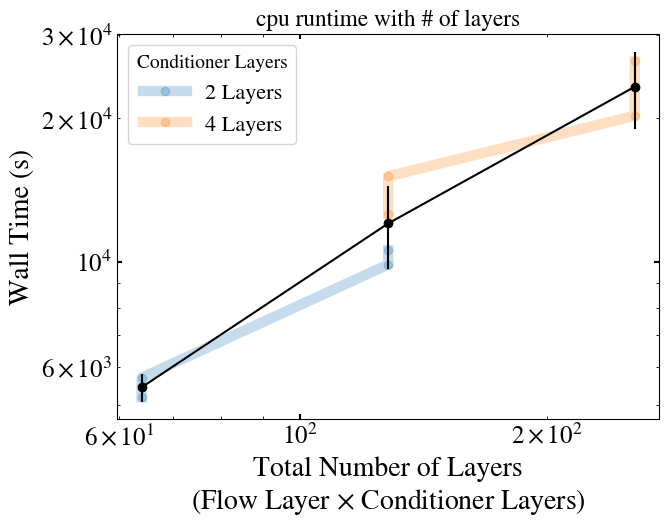

In [14]:
plt.figure(figsize=(7, 5))
device = 'cpu'
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps][df['device'] == device]
    low_thresh_subset = subset[subset['scheduler.threshold'] == low_threshold]
    high_thresh_subset = subset[subset['scheduler.threshold'] == high_threshold]
    plt.errorbar(low_thresh_subset['total_layers'], low_thresh_subset['wall_time_s'], marker='o', label=f'{n_steps} Layers', zorder=0, lw=7.5, alpha=0.25)
    
plt.errorbar(agg_wall_time[agg_wall_time['device'] == device]['total_layers'], agg_wall_time[agg_wall_time['device'] == device]['wall_time_mean'],yerr=agg_wall_time[agg_wall_time['device'] == device]['wall_time_std'],  marker='o', c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Total Number of Layers\n(Flow Layer $\\times$ Conditioner Layers)', fontsize=20)
plt.ylabel('Wall Time (s)', fontsize=20)
plt.legend(title='Conditioner Layers', fontsize=16)
plt.title(f'{device} runtime with # of layers')
plt.show()

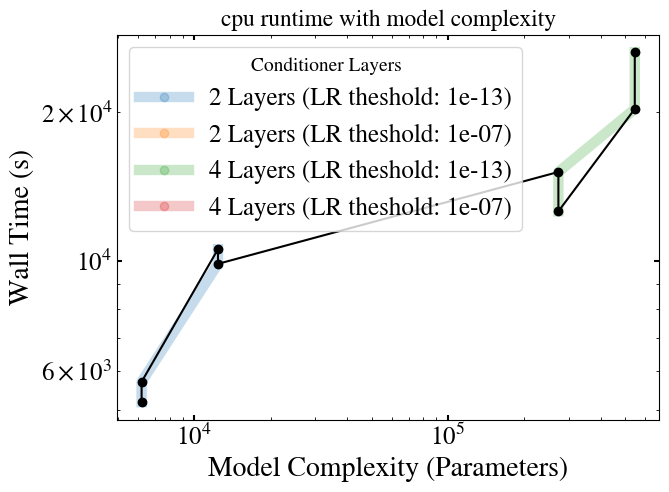

In [15]:
device = 'cpu'
device_mask = df['device'] == device
plt.figure(figsize=(7, 5))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[device_mask][df['model.conditioner.args.num_layers'] == n_steps]
    low_thresh_subset = subset[subset['scheduler.threshold'] == low_threshold]
    high_thresh_subset = subset[subset['scheduler.threshold'] == high_threshold]
    plt.errorbar(low_thresh_subset['model.complexity'], low_thresh_subset['wall_time_s'], marker='o', label=f'{n_steps} Layers (LR theshold: {low_threshold})', zorder=0, lw=7.5, alpha=0.25)
    plt.errorbar(high_thresh_subset['model.complexity'], high_thresh_subset['wall_time_s'], marker='o', label=f'{n_steps} Layers (LR theshold: {high_threshold})', zorder=0, lw=7.5, alpha=0.25)
plt.plot(df[device_mask].sort_values(['model.complexity'])['model.complexity'], df[device_mask].sort_values(['model.complexity'])['wall_time_s'], marker='o', c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Model Complexity (Parameters)', fontsize=20)
plt.ylabel('Wall Time (s)', fontsize=20)
plt.legend(title='Conditioner Layers', fontsize=18)
plt.title(f'{device} runtime with model complexity')
plt.show()

In [16]:
agg_error_eval = df.groupby('model.n_layers').agg(
    eval_mean=('eval_max_error_max', 'mean'),
    eval_std=('eval_max_error_max', 'std'),
).reset_index()

In [17]:
# # plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['wall_time_s'], subset['eval_max_error_max'], marker='o', label=f'{n_steps} Layers')
# plt.xlabel('Training Wall Time (s)', fontsize=20)
# plt.ylabel('Max Energy Error', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Number of Flow Layers')

In [18]:
# plot eval_mean_error_mean as a function of n_orbits, with a separate line for each n_steps
# plt.figure(figsize=(7, 6))
# for n_steps in df['model.n_layers'].unique():
#     subset = df[df['model.n_layers'] == n_steps]
#     plt.errorbar(subset['model.conditioner.args.num_layers'], subset['tail_mean_loss'], yerr=subset['tail_std_loss'], marker='o', label=f'{n_steps} steps')
# plt.xlabel('Number of Orbits', fontsize=20)
# plt.ylabel('Final Loss', fontsize=20)
# plt.yscale('log')
# plt.xscale('log')
# plt.legend(title='Points per Training Orbit')

Do the models converge?


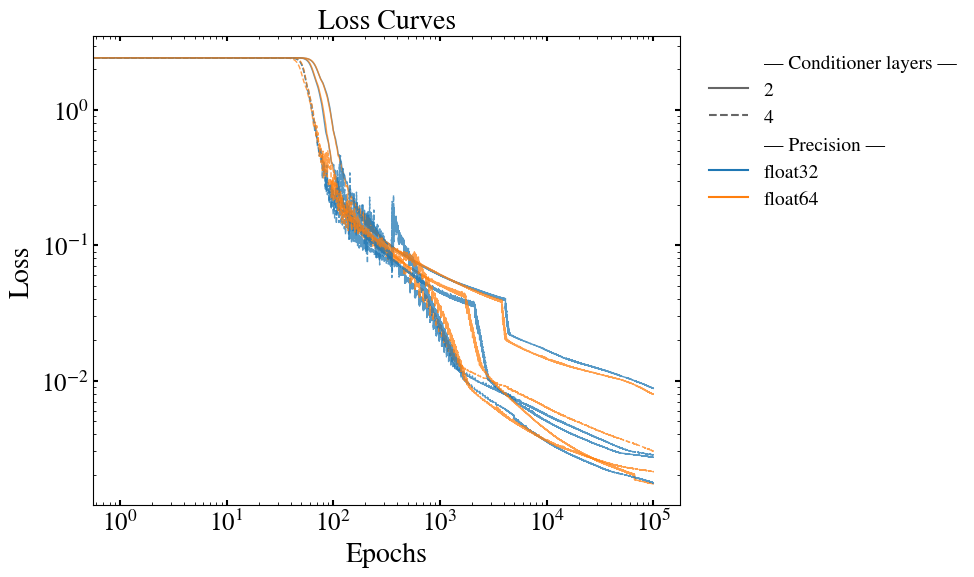

In [19]:
# Per-run loss curves, styled by the same encoding pattern as above.
from itertools import cycle
from matplotlib.lines import Line2D

filepath = Path('results') / 'runs'

encodings = {
    'linestyle':     'model.conditioner.args.num_layers',
    'color': 'dtype'
}
channel_labels = {
    'linestyle':     'Conditioner layers',
    'color': 'Precision',
    'alpha':     'LR threshold',
    'marker':    'Marker',
}
channel_pools = {
    'color':     plt.rcParams['axes.prop_cycle'].by_key()['color'],
    'linestyle': ['-', '--', ':', '-.'],
    'alpha':     [1.0, 0.5, 0.25],
    'marker':    ['o', 's', '^', 'D', 'v'],
}
# Loss curves are dense — no markers, slight transparency by default for overlap.
defaults = {'color': 'C0', 'linestyle': '-', 'alpha': 0.75, 'marker': ''}

style_maps = {
    ch: dict(zip(sorted(df[col].dropna().unique()), cycle(channel_pools[ch])))
    for ch, col in encodings.items()
}

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in df.iterrows():
    loss = np.load(filepath / row['run_id'] / 'loss_curve.npy')
    style = dict(defaults)
    for ch, col in encodings.items():
        style[ch] = style_maps[ch][row[col]]
    ax.plot(loss, lw=1, **style)

handles = []
for ch in encodings:
    handles.append(Line2D([], [], color='none', label=f'— {channel_labels[ch]} —'))
    for value, style_val in style_maps[ch].items():
        kw = {'color': '0.4', 'linestyle': '-', 'alpha': 1.0, 'marker': ''}
        kw[ch] = style_val
        handles.append(Line2D([], [], label=str(value), **kw))

ax.set_xlabel('Epochs', fontsize=20)
ax.set_ylabel('Loss', fontsize=20)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Loss Curves', fontsize=20)
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
plt.show()

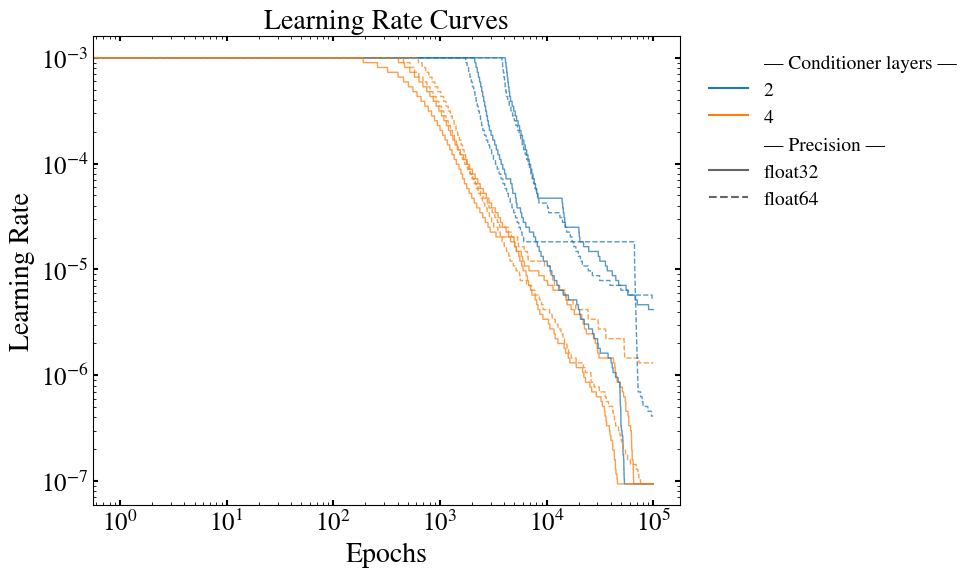

In [20]:
# Per-run loss curves, styled by the same encoding pattern as above.
from itertools import cycle
from matplotlib.lines import Line2D

filepath = Path('results') / 'runs'

encodings = {
    'color':     'model.conditioner.args.num_layers',
    'linestyle': 'dtype'
}
channel_labels = {
    'color':     'Conditioner layers',
    'linestyle': 'Precision',
    'alpha':     'LR threshold',
    'marker':    'Marker',
}
channel_pools = {
    'color':     plt.rcParams['axes.prop_cycle'].by_key()['color'],
    'linestyle': ['-', '--', ':', '-.'],
    'alpha':     [1.0, 0.5, 0.25],
    'marker':    ['o', 's', '^', 'D', 'v'],
}
# Loss curves are dense — no markers, slight transparency by default for overlap.
defaults = {'color': 'C0', 'linestyle': '-', 'alpha': 0.75, 'marker': ''}

style_maps = {
    ch: dict(zip(sorted(df[col].dropna().unique()), cycle(channel_pools[ch])))
    for ch, col in encodings.items()
}

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in df.iterrows():
    loss = np.load(filepath / row['run_id'] / 'lr_curve.npy')
    style = dict(defaults)
    for ch, col in encodings.items():
        style[ch] = style_maps[ch][row[col]]
    ax.plot(loss, lw=1, **style)

handles = []
for ch in encodings:
    handles.append(Line2D([], [], color='none', label=f'— {channel_labels[ch]} —'))
    for value, style_val in style_maps[ch].items():
        kw = {'color': '0.4', 'linestyle': '-', 'alpha': 1.0, 'marker': ''}
        kw[ch] = style_val
        handles.append(Line2D([], [], label=str(value), **kw))

plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Learning Rate', fontsize=20)
plt.yscale('log')
plt.xscale('log')
plt.title('Learning Rate Curves', fontsize=20)
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
plt.show()

# Performance Analysis

$i$ = index of point along an orbit

$j$ = index of orbit

Better results by having more flow layers and fewer conditioner layers.

In [21]:
MAX_FLOW_LAYERS = 512
flow_layer_mask = df['model.n_layers'] <= MAX_FLOW_LAYERS

In [22]:
# import numpy as np
# import matplotlib.pyplot as plt

# df_pivot = df[flow_layer_mask].pivot(
#     index='model.n_layers',
#     columns='model.conditioner.args.num_layers',
#     values='eval_max_error_mean'
# )

# x = df_pivot.columns.to_numpy()   # n_steps
# y = df_pivot.index.to_numpy()     # n_orbits
# z = np.log10(df_pivot.to_numpy())


# x_plot = np.log2(x)
# y_plot = np.log2(y)

# fig, ax = plt.subplots(figsize=(7,7))

# pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

# ax.set_xticks(x_plot)
# ax.set_xticklabels(x)

# ax.set_yticks(y_plot)
# ax.set_yticklabels(y)

# ax.set_aspect('equal')

# # Add text inside each cell
# for i in range(len(y)):
#     for j in range(len(x)):
#         ax.text(
#             x_plot[j],
#             y_plot[i],
#             f"{z[i, j]:.2f}",   # format to 2 decimals
#             ha='center',
#             va='center',
#             fontsize=15
#         )

# fig.colorbar(pcm, label='$\\log_{10} \left ( \left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j} \\right ) $')

# plt.xlabel("Conditioner Layers", fontsize=20)
# plt.ylabel("Flow Layers", fontsize=20)
# plt.title('Mean of the Worst\nErrors along Orbits', fontsize=20)

# # plt.savefig('results/model_size_scaling.png')
# plt.show()


In [23]:
# import numpy as np
# import matplotlib.pyplot as plt

# df_pivot = df[flow_layer_mask].pivot(
#     index='model.n_layers',
#     columns='model.conditioner.args.num_layers',
#     values='eval_max_error_max'
# )

# x = df_pivot.columns.to_numpy()   # n_steps
# y = df_pivot.index.to_numpy()     # n_orbits
# z = np.log10(df_pivot.to_numpy())


# x_plot = np.log2(x)
# y_plot = np.log2(y)

# fig, ax = plt.subplots(figsize=(7,7))

# pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

# ax.set_xticks(x_plot)
# ax.set_xticklabels(x)

# ax.set_yticks(y_plot)
# ax.set_yticklabels(y)

# ax.set_aspect('equal')

# # Add text inside each cell
# for i in range(len(y)):
#     for j in range(len(x)):
#         ax.text(
#             x_plot[j],
#             y_plot[i],
#             f"{z[i, j]:.2f}",   # format to 2 decimals
#             ha='center',
#             va='center',
#             fontsize=15
#         )

# fig.colorbar(pcm, label='$\\log_{10} \left ( \max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right ) \\right )$')

# plt.xlabel("Conditioner Layers", fontsize=20)
# plt.ylabel("Flow Layers", fontsize=20)
# plt.title('Worst Error of\nAll Points', fontsize=20)

# plt.show()


In [24]:
# import numpy as np
# import matplotlib.pyplot as plt

# df_pivot = df[flow_layer_mask].pivot(
#     index='model.n_layers',
#     columns='model.conditioner.args.num_layers',
#     values='eval_mean_error_mean'
# )

# x = df_pivot.columns.to_numpy()   # n_steps
# y = df_pivot.index.to_numpy()     # n_orbits
# z = np.log10(df_pivot.to_numpy())


# x_plot = np.log2(x)
# y_plot = np.log2(y)

# fig, ax = plt.subplots(figsize=(7,7))

# pcm = ax.pcolormesh(x_plot, y_plot, z, shading='auto', cmap='Purples_r')

# ax.set_xticks(x_plot)
# ax.set_xticklabels(x)

# ax.set_yticks(y_plot)
# ax.set_yticklabels(y)

# ax.set_aspect('equal')

# # Add text inside each cell
# for i in range(len(y)):
#     for j in range(len(x)):
#         ax.text(
#             x_plot[j],
#             y_plot[i],
#             f"{z[i, j]:.2f}",   # format to 2 decimals
#             ha='center',
#             va='center',
#             fontsize=15
#         )

# fig.colorbar(pcm, label='$\\log_{10} \left ( \left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j} \\right )$')

# plt.xlabel("Conditioner Layers", fontsize=20)
# plt.ylabel("Flow Layers", fontsize=20)
# plt.title('Mean of the Average\nError Along Orbits', fontsize=20)

# plt.show()

Looking at this plot, I think the curve are cutoff because the training is cut short. Longer training may produce something different.

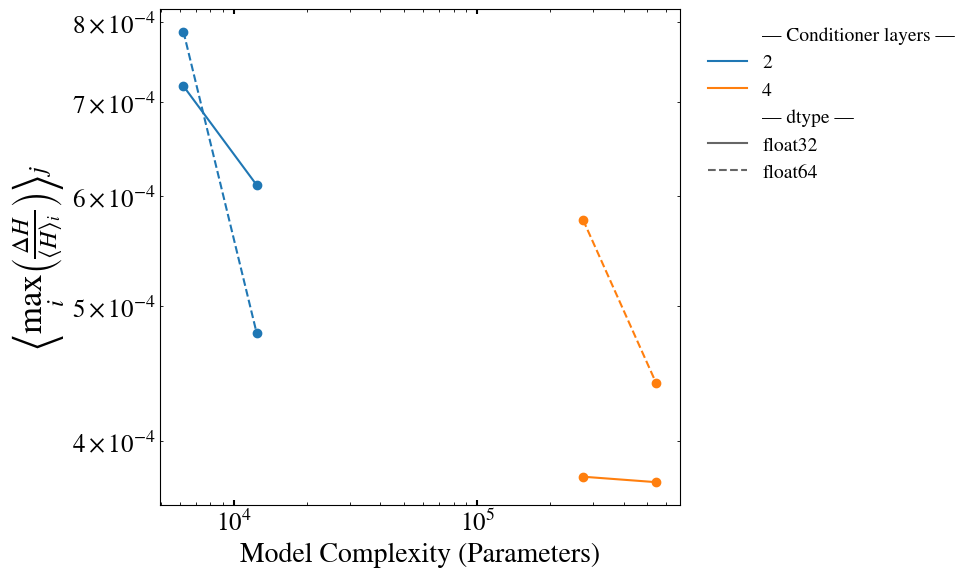

In [25]:
# Same encoding pattern as the wall-time plot. Reassign `encodings` to regroup.
from itertools import cycle
from matplotlib.lines import Line2D

x_col, y_col = 'model.complexity', 'eval_mean_error_max'

encodings = {
    'color':     'model.conditioner.args.num_layers',
    'linestyle': 'dtype'
}
channel_labels = {
    'color':     'Conditioner layers',
    'linestyle': 'dtype',
    'alpha':     'Alpha',
    'marker':    'Marker',
}
channel_pools = {
    'color':     plt.rcParams['axes.prop_cycle'].by_key()['color'],
    'linestyle': ['-', '--', ':', '-.'],
    'alpha':     [1.0, 0.5, 0.25],
    'marker':    ['o', 's', '^', 'D', 'v'],
}
defaults = {'color': 'C0', 'linestyle': '-', 'alpha': 1.0, 'marker': 'o'}

style_maps = {
    ch: dict(zip(sorted(df[col].dropna().unique()), cycle(channel_pools[ch])))
    for ch, col in encodings.items()
}

fig, ax = plt.subplots(figsize=(10, 6))
for keys, sub in df.groupby(list(encodings.values())):
    if not isinstance(keys, tuple):
        keys = (keys,)
    style = dict(defaults)
    for ch, k in zip(encodings.keys(), keys):
        style[ch] = style_maps[ch][k]
    sub = sub.sort_values(x_col)
    ax.plot(sub[x_col], sub[y_col], **style)

handles = []
for ch in encodings:
    handles.append(Line2D([], [], color='none', label=f'— {channel_labels[ch]} —'))
    for value, style_val in style_maps[ch].items():
        kw = {'color': '0.4', 'linestyle': '-', 'alpha': 1.0, 'marker': ''}
        kw[ch] = style_val
        handles.append(Line2D([], [], label=str(value), **kw))

ax.set_xlabel('Model Complexity (Parameters)', fontsize=20)
ax.set_ylabel(r'$\left \langle \max_i \left ( \frac{\Delta H}{\langle H \rangle_{i}} \right ) \right \rangle_{j}$', fontsize=25)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
fig.tight_layout()
plt.show()


### Worst Error of all points


<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_318035/3290139733.py:44: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)


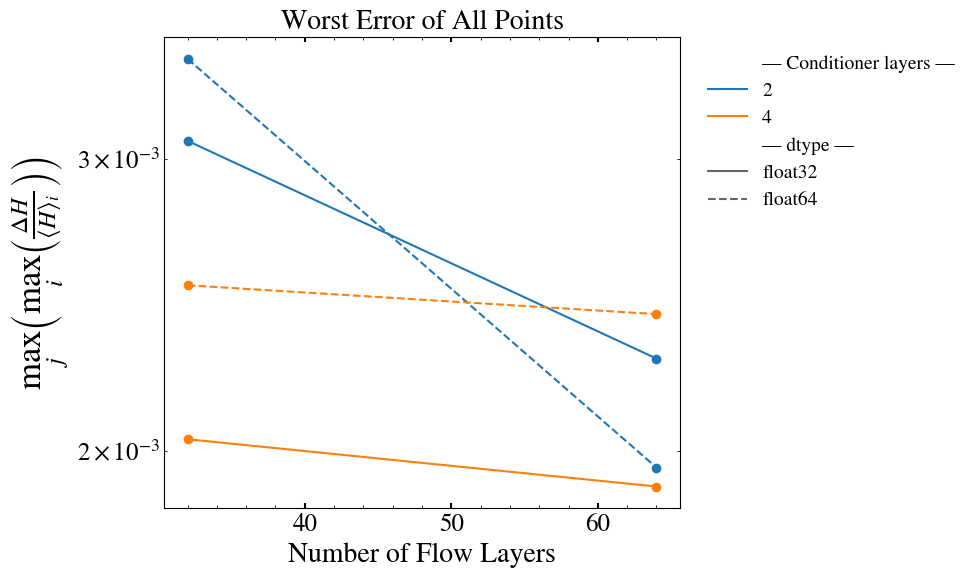

In [26]:
x_col, y_col = 'model.n_layers', 'eval_max_error_max'

encodings = {
    'color':     'model.conditioner.args.num_layers',
    'linestyle': 'dtype'
}
channel_labels = {
    'color':     'Conditioner layers',
    'linestyle': 'dtype',
    'alpha':     'Alpha',
    'marker':    'Marker',
}
channel_pools = {
    'color':     plt.rcParams['axes.prop_cycle'].by_key()['color'],
    'linestyle': ['-', '--', ':', '-.'],
    'alpha':     [1.0, 0.5, 0.25],
    'marker':    ['o', 's', '^', 'D', 'v'],
}
defaults = {'color': 'C0', 'linestyle': '-', 'alpha': 1.0, 'marker': 'o'}

style_maps = {
    ch: dict(zip(sorted(df[col].dropna().unique()), cycle(channel_pools[ch])))
    for ch, col in encodings.items()
}

fig, ax = plt.subplots(figsize=(10, 6))
for keys, sub in df.groupby(list(encodings.values())):
    if not isinstance(keys, tuple):
        keys = (keys,)
    style = dict(defaults)
    for ch, k in zip(encodings.keys(), keys):
        style[ch] = style_maps[ch][k]
    sub = sub.sort_values(x_col)
    ax.plot(sub[x_col], sub[y_col], **style)

handles = []
for ch in encodings:
    handles.append(Line2D([], [], color='none', label=f'— {channel_labels[ch]} —'))
    for value, style_val in style_maps[ch].items():
        kw = {'color': '0.4', 'linestyle': '-', 'alpha': 1.0, 'marker': ''}
        kw[ch] = style_val
        handles.append(Line2D([], [], label=str(value), **kw))
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$\max_j \left ( \max_i \left (\\frac{\Delta H}{\\langle H \\rangle_i} \\right ) \\right )$', fontsize=25)
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.title('Worst Error of All Points', fontsize=20)
plt.yscale('log')
fig.tight_layout()
plt.show()

### Mean of the average error along orbits

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_318035/3348860832.py:44: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)
/tmp/ipykernel_318035/3348860832.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Number of Conditioner Layers')


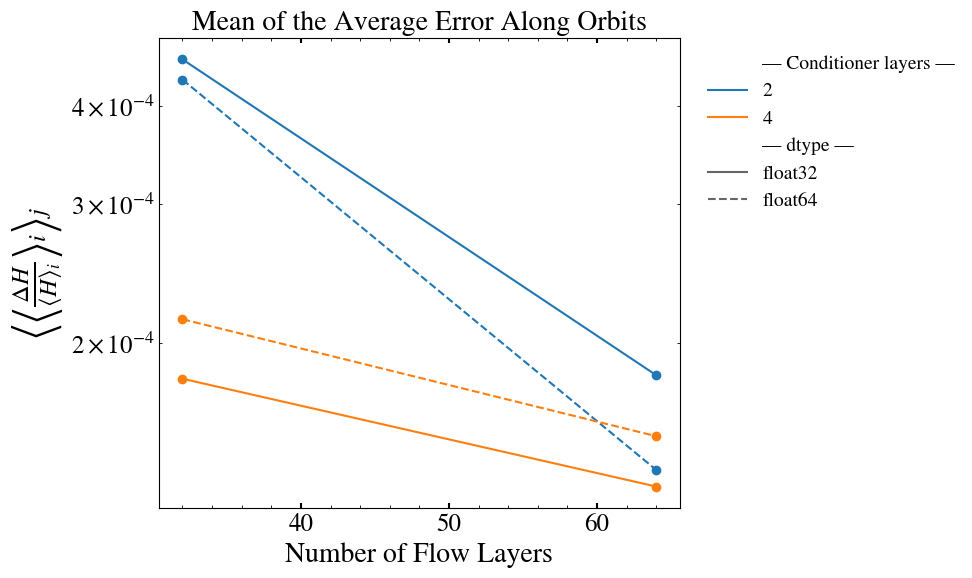

In [27]:
x_col, y_col = 'model.n_layers', 'eval_mean_error_mean'

encodings = {
    'color':     'model.conditioner.args.num_layers',
    'linestyle': 'dtype',
}
channel_labels = {
    'color':     'Conditioner layers',
    'linestyle': 'dtype',
    'alpha':     'Alpha',
    'marker':    'Marker',
}
channel_pools = {
    'color':     plt.rcParams['axes.prop_cycle'].by_key()['color'],
    'linestyle': ['-', '--', ':', '-.'],
    'alpha':     [1.0, 0.5, 0.25],
    'marker':    ['o', 's', '^', 'D', 'v'],
}
defaults = {'color': 'C0', 'linestyle': '-', 'alpha': 1.0, 'marker': 'o'}

style_maps = {
    ch: dict(zip(sorted(df[col].dropna().unique()), cycle(channel_pools[ch])))
    for ch, col in encodings.items()
}

fig, ax = plt.subplots(figsize=(10, 6))
for keys, sub in df.groupby(list(encodings.values())):
    if not isinstance(keys, tuple):
        keys = (keys,)
    style = dict(defaults)
    for ch, k in zip(encodings.keys(), keys):
        style[ch] = style_maps[ch][k]
    sub = sub.sort_values(x_col)
    ax.plot(sub[x_col], sub[y_col], **style)

handles = []
for ch in encodings:
    handles.append(Line2D([], [], color='none', label=f'— {channel_labels[ch]} —'))
    for value, style_val in style_maps[ch].items():
        kw = {'color': '0.4', 'linestyle': '-', 'alpha': 1.0, 'marker': ''}
        kw[ch] = style_val
        handles.append(Line2D([], [], label=str(value), **kw))
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$\left \\langle \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Number of Conditioner Layers')
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.title('Mean of the Average Error Along Orbits', fontsize=20)
plt.yscale('log')
fig.tight_layout()
plt.show()

### Mean of the worst errors along orbits

<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_318035/1940846541.py:9: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)


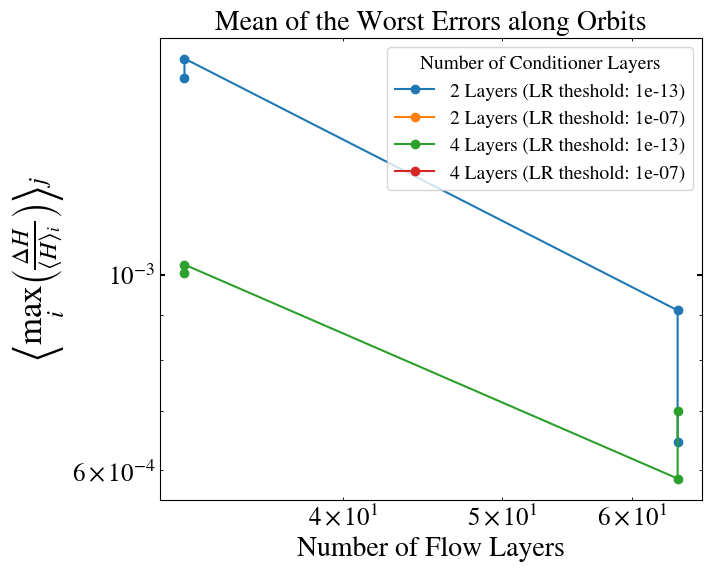

In [28]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps]
    low_thresh_subset = subset[subset['scheduler.threshold'] == low_threshold]
    high_thresh_subset = subset[subset['scheduler.threshold'] == high_threshold]
    plt.loglog(low_thresh_subset['model.n_layers'], low_thresh_subset['eval_max_error_mean'], marker='o', label=f'{n_steps} Layers (LR theshold: {low_threshold})')
    plt.loglog(high_thresh_subset['model.n_layers'], high_thresh_subset['eval_max_error_mean'], marker='o', label=f'{n_steps} Layers (LR theshold: {high_threshold})')
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Number of Conditioner Layers')
plt.title('Mean of the Worst Errors along Orbits', fontsize=20)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_318035/3141904614.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)


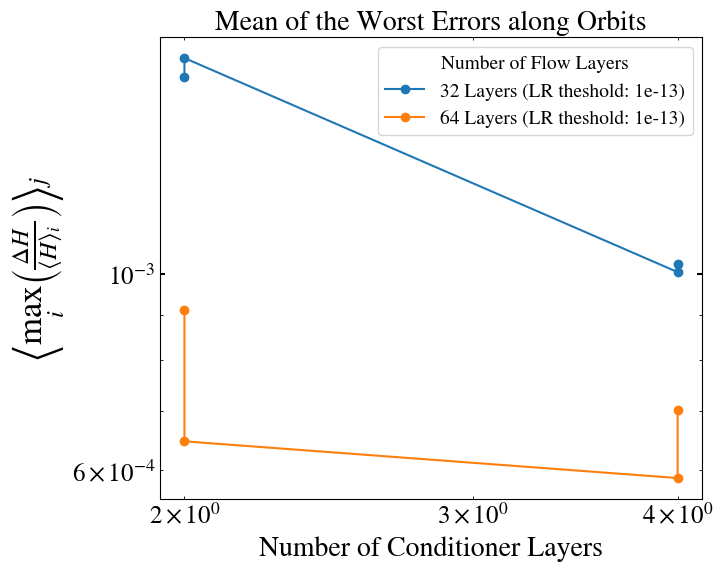

In [29]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.n_layers'].unique():
    subset = df[df['model.n_layers'] == n_steps]
    low_thresh_subset = subset[subset['scheduler.threshold'] == low_threshold]
    high_thresh_subset = subset[subset['scheduler.threshold'] == high_threshold]
    plt.loglog(subset['model.conditioner.args.num_layers'], subset['eval_max_error_mean'], marker='o', label=f'{n_steps} Layers (LR theshold: {low_threshold})')
plt.xlabel('Number of Conditioner Layers', fontsize=20)
plt.ylabel('$\left \\langle \max_i \left ( \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right ) \\right \\rangle_{j}$', fontsize=25)
plt.legend(title='Number of Flow Layers')
plt.title('Mean of the Worst Errors along Orbits', fontsize=20)
plt.show()

### Worst of the mean errors along orbits

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_318035/1941076139.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)


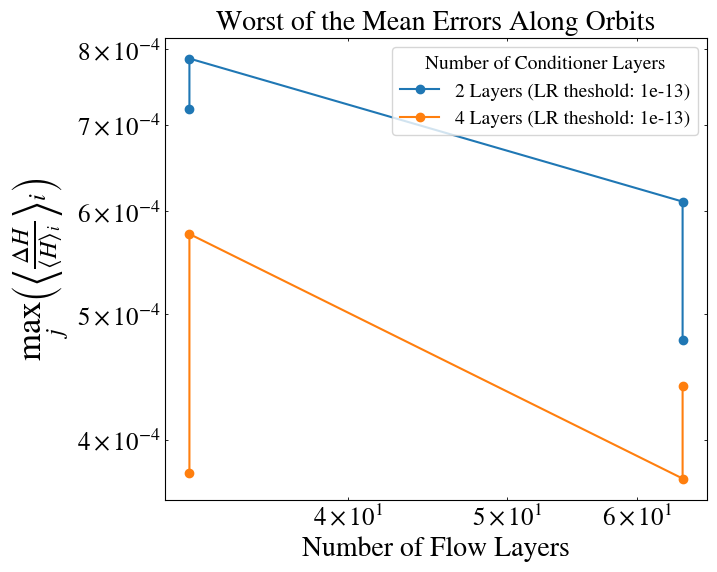

In [30]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.conditioner.args.num_layers'].unique():
    subset = df[df['model.conditioner.args.num_layers'] == n_steps]
    low_thresh_subset = subset[subset['scheduler.threshold'] == low_threshold]
    high_thresh_subset = subset[subset['scheduler.threshold'] == high_threshold]
    plt.loglog(subset['model.n_layers'], subset['eval_mean_error_max'], marker='o', label=f'{n_steps} Layers (LR theshold: {low_threshold})')
plt.xlabel('Number of Flow Layers', fontsize=20)
plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)
plt.legend(title='Number of Conditioner Layers')
plt.title('Worst of the Mean Errors Along Orbits', fontsize=20)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_318035/1132750768.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)


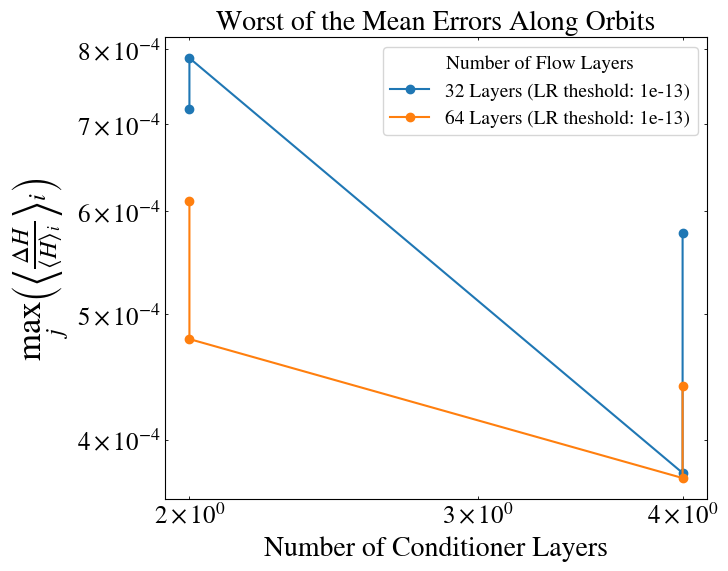

In [31]:
plt.figure(figsize=(7, 6))
for n_steps in df['model.n_layers'].unique():
    subset = df[df['model.n_layers'] == n_steps]
    low_thresh_subset = subset[subset['scheduler.threshold'] == low_threshold]
    high_thresh_subset = subset[subset['scheduler.threshold'] == high_threshold]
    plt.loglog(subset['model.conditioner.args.num_layers'], subset['eval_mean_error_max'], marker='o', label=f'{n_steps} Layers (LR theshold: {low_threshold})')
plt.xlabel('Number of Conditioner Layers', fontsize=20)
plt.ylabel('$ \max_j \left ( \left \\langle \\frac{\Delta H}{\\langle H \\rangle_{i}} \\right \\rangle_{i} \\right )$', fontsize=25)
plt.legend(title='Number of Flow Layers')
plt.title('Worst of the Mean Errors Along Orbits', fontsize=20)
plt.show()